<a href="https://colab.research.google.com/github/john-cant/AMLS2_24_25_SNJCCAN57/blob/main/Task_Multi_Hyper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# AMLS2 Assignment
## Task A: HYPER SRRESNET

Explore Hyperparameters for Multiple Models

## Import libraries
The required libraries for this notebook are sklearn, copy, numpy and matplotlib.

In [ ]:
## first enable autoreload during development so latest (new) version local code library is reloaded on execution
## can be commented out when local code development not happening to avoid overhead
%load_ext autoreload
%autoreload 2

import sys
from psutil import virtual_memory
ram_gb = virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))

if ram_gb < 20:
  print('Not using a high-RAM runtime')
else:
  print('You are using a high-RAM runtime!')

gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

## import libraries
import io
import glob
import os
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
if not os.path.exists('/content/drive/My Drive'):   ## check if Google drive mounted
    from google.colab import drive
    drive.mount('/content/drive')
else:
    print("Google Drive is already mounted.")

sys.path.append('/content/drive/My Drive/AMLS2')       ## load project directory
### print(os.listdir('/content/drive/My Drive/AMLS2'))  ## check by listing files
## load additional functions I have developed to support AMLS assignments
import AMLS_common as ac

## import tensorflow
import tensorflow as tf
print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))
### from tensorflow import keras
from tensorflow.keras import models
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Multiply, Add, Layer, Lambda, LeakyReLU
from tensorflow.keras.layers import Input, Conv2D, Flatten, UpSampling2D, Dropout, BatchNormalization, PReLU
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.losses import BinaryCrossentropy, Hinge, MeanAbsoluteError
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.initializers import Constant
from tensorflow.keras.applications.vgg19 import VGG19
import tensorflow.keras.backend as K
from tensorflow.nn import depth_to_space

from skimage.metrics import structural_similarity as ssim


Your runtime has 89.6 gigabytes of available RAM

You are using a high-RAM runtime!
Thu Apr  3 14:01:19 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P0             68W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |             

## Set base parameters
Including hyperparameters and environment specifics

In [ ]:
## use these lists of values to grid test hyper parameter sensitivity
test_list       = []
batch_list      = [2]
epochs_list     = [2]                        ## defaulted to 2 for main.py test
lr_list         = [0.0001]                    ## learning rates
kerneL_list     = [3]
padding_list    = ['same']
dropout_list    = [0.0]                       ## not used in this scenario
layer_list      = [64]                        ## layers e.g. for srresnet
filter_list     = [128]                       ## main filter sizes to use
loss_list       = ['psnr_loss']               ## loss functions to use
optimise_list   = ['AdamW']                   ## optimisation functions
activation_list = ['prelu']                   ## activation
momentum_list   = [0.9]                       ## momentum
model_list      = [4]                         ## run for all models
test_run        = 'N'
## Loading the data file using a loader
DATA_FLAG      = 'X2'        ## defines which dataset to load
CROP_SIZE      = 224         ## HR crop size
UPSCALE_FACTOR = 2           ## Factor between LR and HR
IMG_SIZE       = 224
## now set up the required hyperparameter sets
for lr in lr_list:
    for bs in batch_list:
        for av in activation_list:
            for ep in epochs_list:
                for fi in filter_list:
                    for op in optimise_list:
                        for ls in loss_list:
                            for ks in kerneL_list:
                                for pd in padding_list:
                                    for ly in layer_list:
                                        for mo in momentum_list:
                                            parameter = ac.HyperParameters(learning_rate=lr,
                                                                          batch_size=bs,
                                                                          num_epochs=ep,
                                                                          optimise=op,
                                                                          loss=ls,
                                                                          num_filter=fi,
                                                                          strides=1,
                                                                          padding="same",
                                                                          dropout_rate=0.0,
                                                                          layers=ly,
                                                                          activation=av,
                                                                          kernel_size=ks,
                                                                          scale=2,
                                                                          momentum=mo,
                                                                          epsilon=0.00001
                                                                          )
                                            test_list.append([parameter])
## reshape parameters into a test grid that can be read using for loop
test_grid = [hp for sublist in test_list for hp in sublist]
print("test cases:",len(test_grid)*len(model_list))

test cases: 8


In [ ]:
## set up lists and parameters
test_list       = []
run_list        = []
patience        = 3                   ## number of overfitting epochs before terminating
threshold       = 0.1                 ## overfitting threshold
## control and environment (e.g. verbose) parameters
filebase        = "metrics/"          ## the folder to store the metrics and summary files generated for each run
verbose         = 0                   ## if value equals 1 then print additional process information in steps below
filebase        = "/content/drive/My Drive/AMLS2/metrics/"   ## place to save output files
## Define training folder paths
lr_train_folder = "/content/drive/My Drive/AMLS2/dataset/track1/train/LR/DIV2K_train_LR_bicubic_X2"
hr_train_folder = "/content/drive/My Drive/AMLS2/dataset/track1/train/HR/DIV2K_train_HR"
## Define validation folder paths
lr_val_folder = "/content/drive/My Drive/AMLS2/dataset/track1/val/LR/DIV2K_valid_LR_bicubic_X2"
hr_val_folder = "/content/drive/My Drive/AMLS2/dataset/track1/val/HR/DIV2K_valid_HR"


#Run the load, model, train and test cycle for each set of hyperparameters

SRRESNET_PLUS 1 / 8 with HyperParameters(learning_rate=0.0001, batch_size=2, num_epochs=15, optimise='AdamW', loss='psnr_loss', num_filter=128, strides=1, padding='same', dropout_rate=0.0, layers=64, activation='prelu', kernel_size=3, scale=2, momentum=0.9, epsilon=1e-05)

Summary metrics for train_dataset
type: <class 'tensorflow.python.data.ops.prefetch_op._PrefetchDataset'>
length: 400
shape: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 448, 448, 3), dtype=tf.float32, name=None))>


Epoch Progress:   0%|          | 0/15 [00:00<?, ?epoch/s]

Epoch 1/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 946ms/step - acc: 0.6007 - loss: -0.2957

Epoch Progress:   7%|▋         | 1/15 [10:35<2:28:22, 635.89s/epoch, acc=0.696, loss=-0.35, val_acc=0.793, val_loss=-0.403]

400/400 ━━━━━━━━━━━━━━━━━━━━ 636s 1s/step - acc: 0.6010 - loss: -0.2958 - val_acc: 0.7934 - val_loss: -0.4030
Epoch 2/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 946ms/step - acc: 0.8169 - loss: -0.4078

...

Epoch Progress:  93%|█████████▎| 14/15 [1:36:40<06:37, 397.85s/epoch, acc=0.848, loss=-0.454, val_acc=0.848, val_loss=-0.457]

400/400 ━━━━━━━━━━━━━━━━━━━━ 397s 984ms/step - acc: 0.8446 - loss: -0.4549 - val_acc: 0.8477 - val_loss: -0.4565
Epoch 15/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 944ms/step - acc: 0.8394 - loss: -0.4526

Epoch Progress: 100%|██████████| 15/15 [1:43:16<00:00, 397.42s/epoch, acc=0.845, loss=-0.455, val_acc=0.809, val_loss=-0.455]

400/400 ━━━━━━━━━━━━━━━━━━━━ 396s 984ms/step - acc: 0.8394 - loss: -0.4526 - val_acc: 0.8093 - val_loss: -0.4548


Epoch Progress: 100%|██████████| 15/15 [1:43:16<00:00, 413.11s/epoch, acc=0.845, loss=-0.455, val_acc=0.809, val_loss=-0.455]


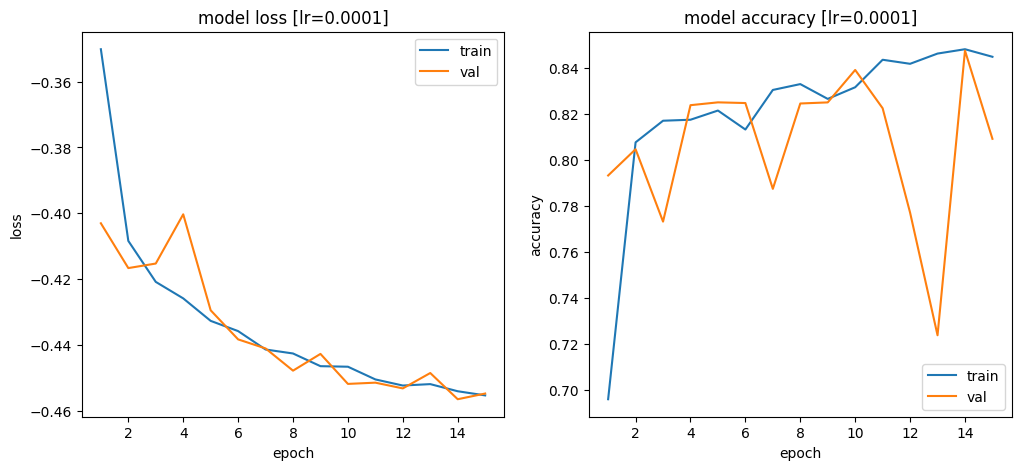

metrics_df ['acc', 'loss', 'val_acc', 'val_loss'] ['epoch', 'acc', 'loss', 'val_acc', 'val_loss']
Files saved: /content/drive/My Drive/AMLS2/metrics/metrics_2025_04_03_at_154446.xlsx /content/drive/My Drive/AMLS2/metrics/summary_2025_04_03_at_154446.txt



SRRESNET_PLUS 2 / 8 with HyperParameters(learning_rate=0.0001, batch_size=2, num_epochs=15, optimise='Adam', loss='psnr_loss', num_filter=128, strides=1, padding='same', dropout_rate=0.0, layers=64, activation='prelu', kernel_size=3, scale=2, momentum=0.9, epsilon=1e-05)

Summary metrics for train_dataset
type: <class 'tensorflow.python.data.ops.prefetch_op._PrefetchDataset'>
length: 400
shape: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 448, 448, 3), dtype=tf.float32, name=None))>


Epoch Progress:   0%|          | 0/15 [00:00<?, ?epoch/s]

Epoch 1/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 947ms/step - acc: 0.6268 - loss: -0.2978

Epoch Progress:   7%|▋         | 1/15 [10:10<2:22:27, 610.54s/epoch, acc=0.711, loss=-0.352, val_acc=0.777, val_loss=-0.402]

400/400 ━━━━━━━━━━━━━━━━━━━━ 611s 1s/step - acc: 0.6270 - loss: -0.2979 - val_acc: 0.7767 - val_loss: -0.4018
Epoch 2/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 946ms/step - acc: 0.8177 - loss: -0.4067

...

Epoch Progress:  93%|█████████▎| 14/15 [1:36:24<06:38, 398.91s/epoch, acc=0.848, loss=-0.45, val_acc=0.815, val_loss=-0.431] 

400/400 ━━━━━━━━━━━━━━━━━━━━ 398s 987ms/step - acc: 0.8503 - loss: -0.4531 - val_acc: 0.8145 - val_loss: -0.4314
Epoch 15/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 947ms/step - acc: 0.8517 - loss: -0.4530

Epoch Progress: 100%|██████████| 15/15 [1:43:02<00:00, 398.63s/epoch, acc=0.849, loss=-0.454, val_acc=0.849, val_loss=-0.459]

400/400 ━━━━━━━━━━━━━━━━━━━━ 398s 987ms/step - acc: 0.8517 - loss: -0.4530 - val_acc: 0.8490 - val_loss: -0.4589


Epoch Progress: 100%|██████████| 15/15 [1:43:02<00:00, 412.20s/epoch, acc=0.849, loss=-0.454, val_acc=0.849, val_loss=-0.459]


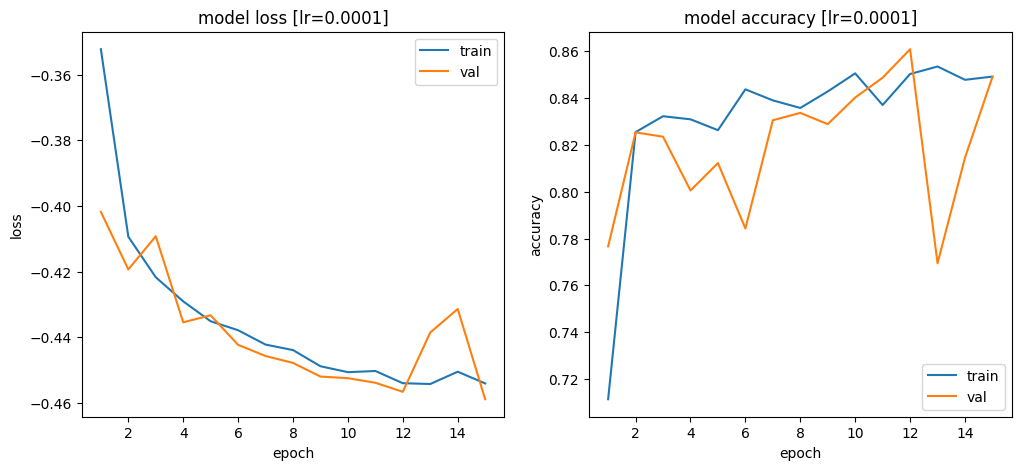

metrics_df ['acc', 'loss', 'val_acc', 'val_loss'] ['epoch', 'acc', 'loss', 'val_acc', 'val_loss']
Files saved: /content/drive/My Drive/AMLS2/metrics/metrics_2025_04_03_at_172756.xlsx /content/drive/My Drive/AMLS2/metrics/summary_2025_04_03_at_172756.txt



SRRESNET_PLUS 3 / 8 with HyperParameters(learning_rate=0.0001, batch_size=2, num_epochs=15, optimise='AdamW', loss='psnr_loss', num_filter=128, strides=1, padding='same', dropout_rate=0.0, layers=64, activation='relu', kernel_size=3, scale=2, momentum=0.9, epsilon=1e-05)

Summary metrics for train_dataset
type: <class 'tensorflow.python.data.ops.prefetch_op._PrefetchDataset'>
length: 400
shape: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 448, 448, 3), dtype=tf.float32, name=None))>


NameError: name 'layers' is not defined

In [ ]:
folderbase   = '/content/drive/My Drive/AMLS2/'            ## project folder
## Initialize hyperparameters
## set up the variables to keep track of the hyperparameter combinations
iterations      = len(test_grid)*len(model_list)                      ## number of hyperparameter sets * models to run
countie         = 0                                                   ## interim count for iterations in loop
stop_overfit_cb = ac.StopOverfittingCallback(patience, threshold)     ## initialise overfitting callback
## Create instances of the dataclass from the list
model_choice = 3
for item in test_grid:
  for model_choice in model_list:
    countie += 1
    BATCH_SIZE     = item.batch_size
    loss_fn        = "ac."+item.loss
    ##print(ac.HyperParameters.list_parameters(item))

    tqdm_callback = ac.TqdmEpochProgress(total_epochs=item.num_epochs)
    if model_choice == 1:
      print("SRRESNET_BASE",countie,"/",iterations,"with",item)
      ## Define the model
      UPSCALE_FACTOR = 4           ## Factor between LR and HR
      train_dataset,val_dataset = ac.load_data(lr_train_folder,hr_train_folder,lr_val_folder,hr_val_folder,BATCH_SIZE,UPSCALE_FACTOR)
      model = ac.srresnet_base(int(item.num_filter),float(item.dropout_rate))
      if item.loss == "ssim_loss":
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=item.learning_rate), ## Use item.learning_rate
                      loss= ac.ssim_loss,                                          ## ssim loss
                      metrics=['acc'])
      else:
        if item.loss == "psnr_loss":
          model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=item.learning_rate), ## Use item.learning_rate
                        loss= ac.psnr_loss,                                          ## psnr loss
                        metrics=['acc'])
    if model_choice == 2:
      print("EDSR",countie,"/",iterations,"with",item)
      UPSCALE_FACTOR = 4           ## Factor between LR and HR
      train_dataset,val_dataset = ac.load_data(lr_train_folder,hr_train_folder,lr_val_folder,hr_val_folder,BATCH_SIZE,UPSCALE_FACTOR)
      model = ac.edsr(128,64)
      if item.loss == "ssim_loss":
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=item.learning_rate), ## Use item.learning_rate
                      loss= ac.ssim_loss,                                          ## ssim loss
                      metrics=['acc'])
      else:
        if item.loss == "psnr_loss":
          model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=item.learning_rate), ## Use item.learning_rate
                        loss= ac.psnr_loss,                                          ## psnr loss
                        metrics=['acc'])
    if model_choice == 3:
      print("SRRESNET_TUNE",countie,"/",iterations,"with",item)
      UPSCALE_FACTOR = 2           ## Factor between LR and HR
      train_dataset,val_dataset = ac.load_data(lr_train_folder,hr_train_folder,lr_val_folder,hr_val_folder,BATCH_SIZE,UPSCALE_FACTOR)
      model = ac.srresnet_tune(item)

    if model_choice == 4:
      print("SRRESNET_PLUS",countie,"/",iterations,"with",item)
      UPSCALE_FACTOR = 2           ## Factor between LR and HR
      train_dataset,val_dataset = ac.load_data(lr_train_folder,hr_train_folder,lr_val_folder,hr_val_folder,BATCH_SIZE,UPSCALE_FACTOR)
      model = ac.srresnet_plus(item)

    if verbose == 1:
      print(model.summary())
      print(item.num_epochs)
      ## nvidia-smi check.
      !nvidia-smi

    ## Redirect the summary output to a string
    summary_string = io.StringIO()
    model.summary(print_fn=lambda x: summary_string.write(x + "\n"))
    summary_content = summary_string.getvalue()
    summary_string.close()

    steps_per_epoch  = len(train_dataset)  ## Understand dataset already adjusted by batch
    validation_steps = len(val_dataset)    ## Also set up validation

    if verbose == 1:
        print("steps",steps_per_epoch,"val_steps",validation_steps)

    history = model.fit(
        train_dataset,
        epochs                =item.num_epochs,     ## Total number of epochs
        steps_per_epoch       =steps_per_epoch,     ## Number of steps per epoch
        validation_data       =val_dataset,         ## Validation dataset
        validation_steps      =validation_steps,    ## Number of steps
        verbose=1,                                  ## Set to 1 for progress updates
        callbacks=[tqdm_callback]                   ## Bar to show progress during run
    )

    ## Save results
    run_list.append(ac.hyper_process(history,summary_content,item))
    ## output graphs and save metrics files
    ac.graph_and_save(history,summary_content,item,filebase)
    if test_run == "Y":
      ac.test_model(val_dataset,model,BATCH_SIZE,filebase)
    print("\n\n")
    ## clear out memory and resources for each iteration
    del model                                                ## Delete the model
    del train_dataset, val_dataset                           ## Delete data variables
    K.clear_session()                                        ## Improved session resources cleardown
    ## end of loop
print("Hyperparameter test run complete")

In [ ]:
## Get best hyperparameter sets and both print them out and save them to parameter files that can be fed to Tune model runs
run_df,best_run,best_run2,best_run3 = ac.analyse_run(run_list," ",filebase)
print("\nRun satisfying both smallest min_loss and largest max_acc:")
if len(best_run) > 0:
    ac.process_best_run(best_run)
print("\n")
print("\nRun with largest max_acc that is plateau or increasing:")
if len(best_run2) > 0:
    ac.process_best_run(best_run2)
print("\n")
print("\nRun with smallest min_loss that is plateau or decreasing:")
if len(best_run3) > 0:
    ac.process_best_run(best_run3)

if len(run_df)>1:
    feature_importance,coef = ac.analyse_hyperparameters(run_df)
    print("\nImpact of Hyperparameters on Accuracy (from Linear Regression):")
    print(coef)
    print("\nHyperparameter Importance for Accuracy (from Random Forest):")
    print(feature_importance)
else:
    print("\n")
    print('Suppressed feature analysis as train set too small')
